## Introduction to Data Science

#### University of Redlands - DATA 101
#### Prof: Joanna Bieri [joanna_bieri@redlands.edu](mailto:joanna_bieri@redlands.edu)
#### [Class Website: data101.joannabieri.com](https://joannabieri.com/data101.html)

---------------------------------------
# Homework Day 15
---------------------------------------

GOALS:

1. Practice making plots
2. Add trendlines to plots
3. Explore Linear Regression

----------------------------------------------------------

This homework has **4 questions** and **3 exercises**.


## Help with Algorithms!

Implementing algorithms can be very difficult. I would highly suggest that you **start by recreating the code that you see in the lecture**... copy and paste it and make sure it runs. THEN try to alter that code to do the exercises.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

# This stops a few warning messages from showing
pd.options.mode.chained_assignment = None 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# Load the Data
file_location = 'https://joannabieri.com/introdatascience/data/paris-paintings.csv'
DF_raw_paintings = pd.read_csv(file_location,na_filter=False)

In [3]:
show(DF_raw_paintings)

Loading ITables v2.5.2 from the internet... (need help?)


In [4]:
# Make a copy of the data that we can start working on
DF = DF_raw_paintings.copy()

# Do something about all those different NaNs
DF.replace('',np.nan,inplace=True)
DF.replace('n/a',np.nan,inplace=True)
DF.replace('NaN',np.nan,inplace=True)

**Q1** Make historgrams of the height and width of all the paintings in the data set. You should be able to recreate the plots from the lecture without looking at the code.

Don't forget to change the values into floats liek we did in the lecture!

In [5]:
DF['Height_in'] = DF['Height_in'].apply(lambda x: float(x))
DF['Width_in'] = DF['Width_in'].apply(lambda x: float(x))

In [6]:
height_histo = px.histogram(
    DF,
    x='Height_in',
    title='Heights of Paintings'
)
height_histo.update_layout(
    xaxis_title='Height (inches)',
)
height_histo.show()

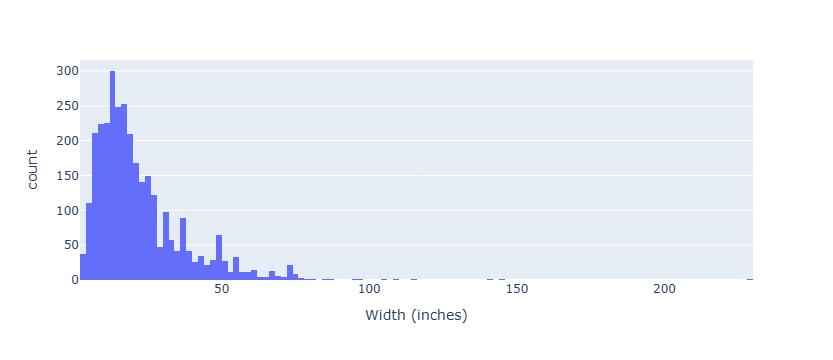

In [7]:
width_histo = px.histogram(
    DF,
    x='Width_in'
)
width_histo.update_layout(
    xaxis_title='Width (inches)'
)
width_histo.show()

**Q2** Explain in words what these plots tell you about the data.

These plots tell me that the data is right-skewed and paintings tend to have smaller axes rather than larger. However, the plots doesn't tell us that much unless they're plotted with each other.


**Q3** Make a scatter plot of the width vs the height like the one in the lecture. You should be able to recreate the plots here without looking at the code.

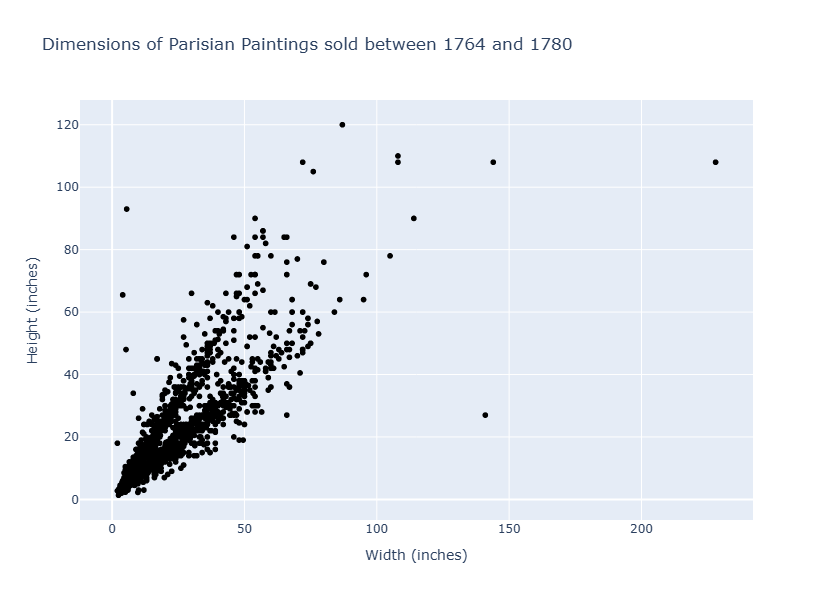

In [18]:
size = px.scatter(
    DF,
    x='Width_in',
    y='Height_in',
    color_discrete_sequence=['black'],
    title='Dimensions of Parisian Paintings sold between 1764 and 1780',
    height=600
)
size.update_layout(
    xaxis_title='Width (inches)',
    yaxis_title='Height (inches)'
)
size.show()

The plot below uses Ordinary Least Squares fitting to find a reasonable line.

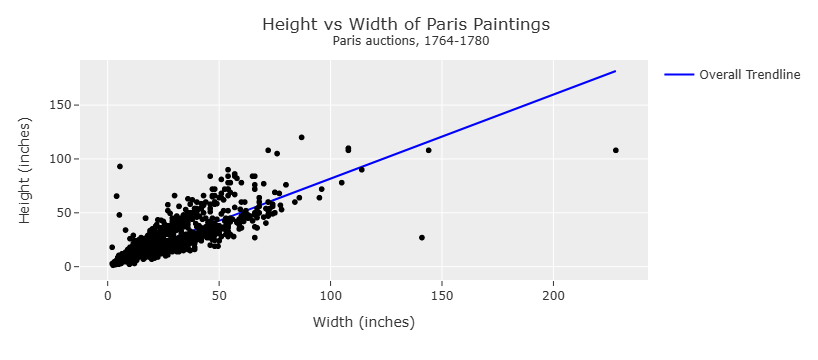

In [20]:
# Example Code Trendline

DF['Height_in'] = DF['Height_in'].apply(lambda x: float(x))
DF['Width_in'] = DF['Width_in'].apply(lambda x: float(x))

fig = px.scatter(DF,
                 x='Width_in',
                 y="Height_in",
                 color_discrete_sequence=['black'],
                trendline='ols',
                trendline_scope='overall',
                trendline_color_override='blue')


fig.update_layout(template="ggplot2",
                  title='Height vs Width of Paris Paintings <br><sup> Paris auctions, 1764-1780</sup>',
                  title_x=0.5,
                  xaxis_title="Width (inches)",
                  yaxis_title="Height (inches)")

fig.show()

So the line that "fits" this data based on the code we ran is

$$ H = 0.7808 W + 3.6214 $$

**Q4** Where do we think this prediction is most accurate? Where is there the most error? Explain why you think this?

The prediction is the most accurate for the data points closest to the line, around the cluster at the lower values. The prediction struggles to accurately represent the larger values, but it makes that sacrifice in order to more accurately predict the large blob of the smaller values.

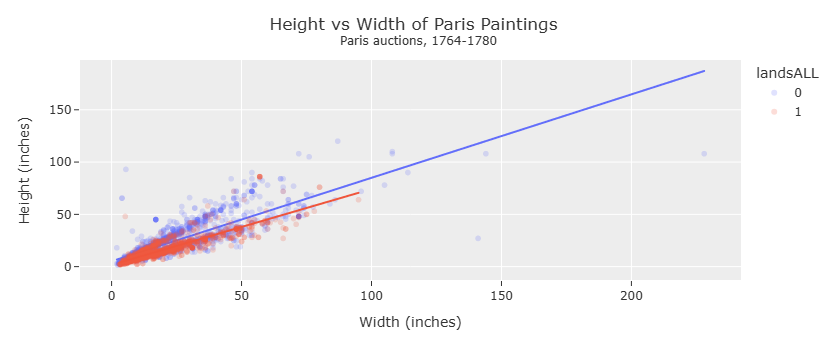

In [21]:
# Example Code Trendline with Categories
DF['landsALL'] = DF['landsALL'].apply(lambda x: str(x))

fig = px.scatter(DF,
                 x='Width_in',
                 y="Height_in",
                 color='landsALL',
                 opacity=0.2,
                 trendline='ols')

fig.update_layout(template="ggplot2",
                  title='Height vs Width of Paris Paintings <br><sup> Paris auctions, 1764-1780</sup>',
                  title_x=0.5,
                  xaxis_title="Width (inches)",
                  yaxis_title="Height (inches)")

fig.show()

IN the plot above we added another variable by coloring by whether or not there were landscape features in the painting. Then the trendline='ols' now gives us two lines. Here there is some evidence that if a painting in landscape, then it tends to be wider than it is tall.

**Exercise 1** Redo the plot above except color by some other variable that takes values of zero or one. Describe what the ols trendline tells you about the height and width of that type of painting. Eg. Does a painting being described as pastoral mean it is taller or wider than if it is not pastoral?

1. Choose a column that has just 0 and 1 as entries
2. Change those values into strings using apply and lambda
3. Do a value counts and talk about the balance in the data
4. Create a scatter plot with an old trendline colored by your focal column
5. Describe in words what you plot is telling you.

In [11]:
DF['mytho'] = DF['mytho'].apply(lambda x: str(x))
DF['mytho'].value_counts()

mytho
0    3034
1     359
Name: count, dtype: int64

There are mostly non-mythological paintings in the data set. The mythological paintings make up around 10% of the data set.

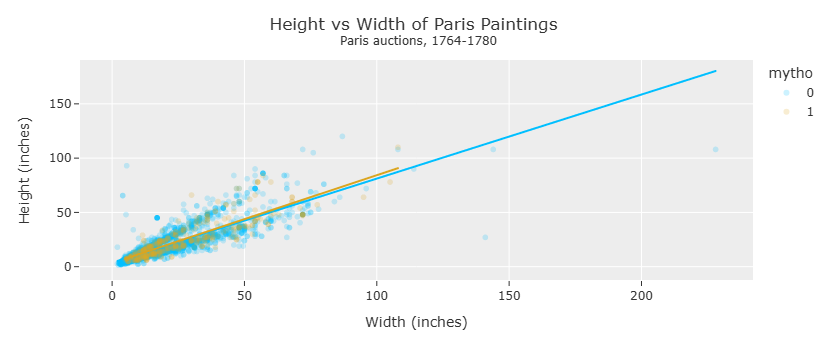

In [13]:
mythoscatter = px.scatter(DF,
                 x='Width_in',
                 y="Height_in",
                 color='mytho',
                 opacity=0.2,
                 trendline='ols',
                 color_discrete_sequence=['deepskyblue', 'goldenrod'])

mythoscatter.update_layout(template="ggplot2",
                  title='Height vs Width of Paris Paintings <br><sup> Paris auctions, 1764-1780</sup>',
                  title_x=0.5,
                  xaxis_title="Width (inches)",
                  yaxis_title="Height (inches)")

mythoscatter.show()

The plot is telling me that the trendlines for mythological and non-mythological paintings within the data set is roughly the exact same, with the non-mythological trendline formula being 0.77435W+3.70314 and the mythological trendline formula being 0.810236W+3.27158. The mythological trendline is a bit more accurate, though, as it has an R^2 of 0.735859 whereas the non-mythological trendline has an R^2 of 0.669596.


## Install Scikit-Learn

Run the code below to install sklearn.

```{python}
    !conda install -y scikit-learn
```

In [13]:
# !conda install -y scikit-learn

^C
Jupyter detected...

3 channel Terms of Service accepted

==> WARNING: A newer version of conda exists. <==


    current version: 25.7.0

Retrieving notices: done


...

Please update conda by running

 - defaults


    $ conda update -n base -c conda-forge conda

Platform: win-64


Solving environment: done

# All requested packages already installed.



In [17]:
# A new packages to import!
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import OneHotEncoder

**Exercise 2** Redo the Linear Regression from the lecture to see if you can use the size ('Surface') of the painting to predict the price.

1. Create a data frame with only the price and surface columns
2. Look at the data types
3. Preprocess the data - remove NaNs and change the Surface values to floats.
5. Train a linear regression model that takes as an input X = Surface Area and gives as an output y=price

           X = DF_model['Surface'].values.reshape(-1,1)
           y = DF_model['price'].values
7. Plot a scatter plot of Price vs Surface add in your predicted line
8. Find your slope and intercept
9. Look at the score

Interpret your results. Should you use a linear model to predict the price of a painting using the surface area?

*In the lecture you can see the scatter plot and score that I got.*


### Preprocessing the Data

Before you can build a model you need to do some cleaning and preprocessing of your data. Here are some important steps:

1. Select the variables that you wan to use (columns)
2. Decide what to do about NaNs or other strange data
3. (*advanced*) Think about rescaling and standardizing
4. Create the inputs and outputs (sometimes encode)
5. (*advanced*) Test - Train split

### Train the model

1. Create the base model, in this case LinearRegression()
2. Train the model using the training data
3. Look at the results.


In [15]:
DF_tired = pd.DataFrame(DF[['Surface', 'price']].dropna())
DF_tired['Surface'] = DF_tired['Surface'].apply(lambda x: float(x))
DF_tired.dtypes

Surface    float64
price      float64
dtype: object

In [25]:
LM = LinearRegression()
LM.fit(DF_tired['Surface'].values.reshape(-1,1), DF_tired['price'].values)
LM.coef_

array([0.1876263])

In [26]:
LM.intercept_

np.float64(660.1215276728371)

In [30]:
DF_model = pd.DataFrame()
DF_model['x'] = DF_tired['Surface']
DF_model['y'] = LM.coef_*DF_model['x']+LM.intercept_
DF_model = DF_model.sort_values('x')

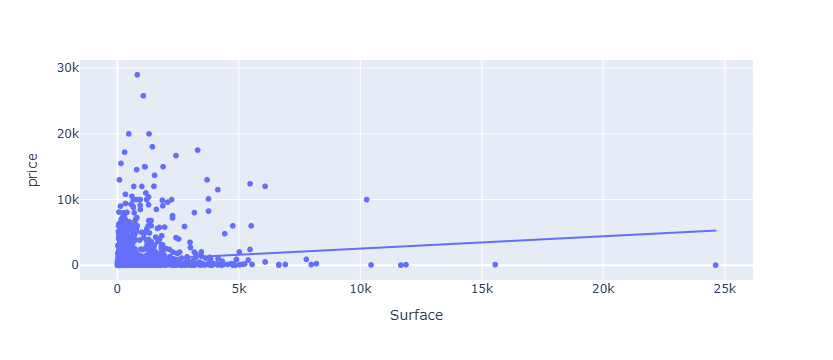

In [32]:
fig = px.scatter(DF_tired, x='Surface', y='price')
fig.add_trace(px.line(DF_model, x='x', y='y').data[0])
fig.show()

In [35]:
LM.score(DF_tired['Surface'].values.reshape(-1,1), DF_tired['price'].values)

0.011141075251450694

No, you should probably not be using a linear model for this data.

**Exercise 3** Redo the analysis for Linear Regression with more than one categorical value (from the lecture) except this time see if the school of the painting effects the overall size ('Surface') of the painting. Don't forget to drop the NaNs where we don't know the surface size and change the surface variables to floats.

1. Create a data frame with only the school and surface columns
2. Look at the data types
3. Preprocess the data - remove NaNs and change the Surface values to floats.
5. Train a linear regression model that takes as an input X = School and gives as an output y= surface area, now you need to one hot encode the X values!

           X = DF_model['school_pntg'].values.reshape(-1,1)
           y = DF_model['Surface'].values
   
9. Look at the output, what does it mean?
        - Which school of paintings on average are largest? smallest?

*You can see the outputs of my code in the lecture*


In [36]:
DF_g = pd.DataFrame(DF[['Surface', 'school_pntg']])

In [37]:
DF_g

,Surface,school_pntg
0,1091.5,F
1,252,I
2,208,D/FL
3,252,F
4,252,F
...,...,...
3388,387,F
3389,214.5,F
3390,720,F
3391,621,F


In [38]:
DF_g.dtypes

Surface        object
school_pntg    object
dtype: object

In [39]:
DF_g = DF_g.dropna()

In [43]:
DF_g['Surface'] = DF_g['Surface'].apply(lambda x: float(x))

In [46]:
X = DF_g['school_pntg'].values.reshape(-1,1)
Y = DF_g['Surface'].values

encoder = OneHotEncoder()
X = encoder.fit_transform(X)

In [48]:
result = DF_g.groupby('school_pntg',as_index=False).first()
encoded_data = encoder.transform(result['school_pntg'].values.reshape(-1,1))

In [52]:
LM = LinearRegression()
LM.fit(X, Y)

categories = encoder.categories_[0]
print(categories)
print('------------------------------')
print(LM.coef_)
print('------------------------------')
print(LM.intercept_)

['A' 'D/FL' 'F' 'G' 'I' 'S' 'X']
------------------------------
[-392.07405523 -266.70340379  122.28764952 -393.21155602  142.65081705
 1051.64022981 -264.58968134]
------------------------------
686.0740374961941


On average, the 'S' paintings are the largest, and the 'G' paintings are the smallest, although the 'A' paintings are close behind.